# Partie A: Clustering

- **Dataset**: Mall Customer Segmentation Data
- **Objectifs**: Segmenter les clients du centre commercial en groupes homogènes.

In [17]:
# Importation des librairies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Chargement:
Chargement du fichier `Mall_Customer.csv`

In [3]:
# Chargement du DataSet
dataset=pd.read_csv('../dataset/Mall_Customers.csv')
dataset.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# 2. Nettoyage et prétraitement:

In [ ]:
# Nettoyage et prétraitement
##  Gender : Supprimer les NaN
dataset['Gender'].dropna(inplace=True)
##  TODO Age: Superieure à 18
dataset['Age']=dataset['Age'].fillna(18)
## TODO Annual Income: Positifs

## TODO Spending Score: Entre 1-100

## Remplacer:
##   Male   par 0
##   Female par 1
dataset['Gender']=dataset['Gender'].replace({"Male":0,"Female":1})
dataset.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,0,19,15,39
1,2,0,21,15,81
2,3,1,20,16,6
3,4,1,23,16,77
4,5,1,31,17,40


# 3. EDA univariée et multivariée :

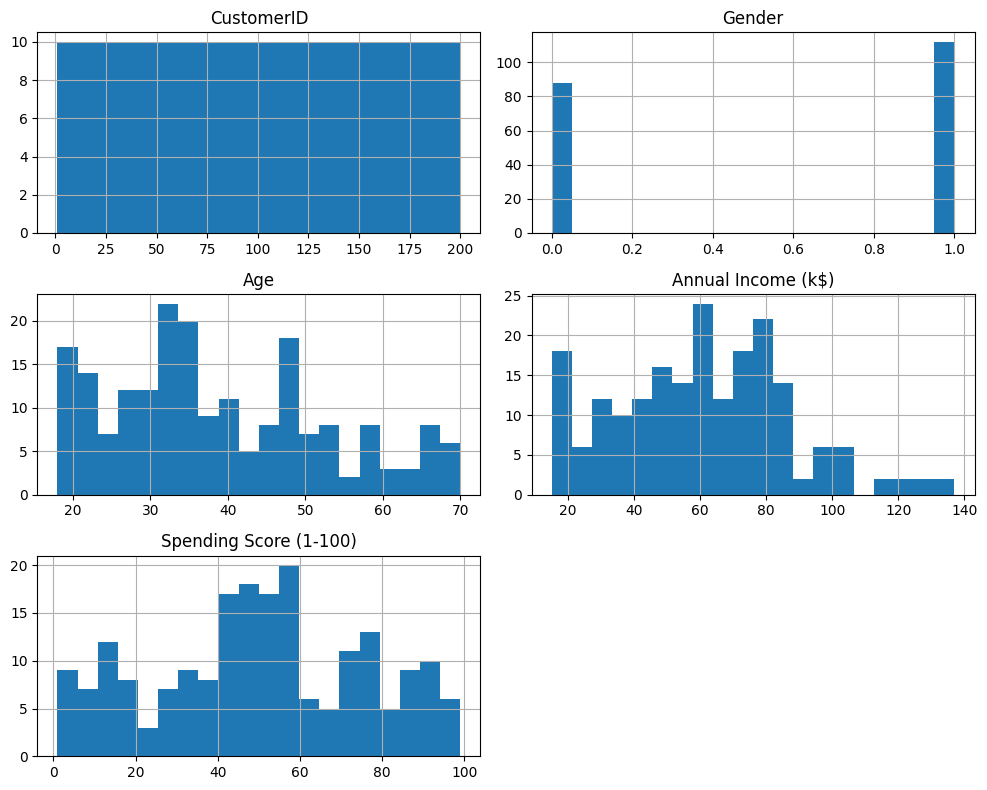

In [5]:
# Histogramme de Chaque Variables
dataset.hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

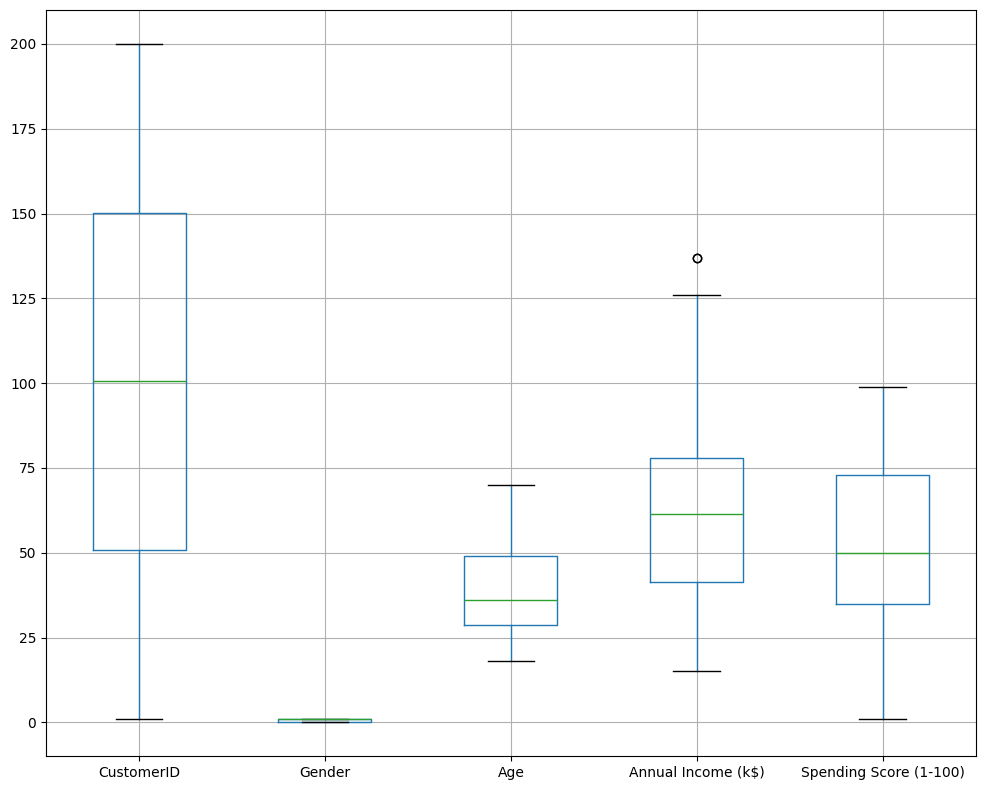

In [ ]:
# BoxLayout de Chaque Variables
# TODO : Modifier en Subplot pour chaque Variable
dataset.boxplot(figsize=(10, 8))
plt.tight_layout()
plt.show()

La matrice de Correlation :                         CustomerID    Gender       Age  Annual Income (k$)  \
CustomerID                1.000000 -0.057400 -0.026763            0.977548   
Gender                   -0.057400  1.000000 -0.060867           -0.056410   
Age                      -0.026763 -0.060867  1.000000           -0.012398   
Annual Income (k$)        0.977548 -0.056410 -0.012398            1.000000   
Spending Score (1-100)    0.013835  0.058109 -0.327227            0.009903   

                        Spending Score (1-100)  
CustomerID                            0.013835  
Gender                                0.058109  
Age                                  -0.327227  
Annual Income (k$)                    0.009903  
Spending Score (1-100)                1.000000  


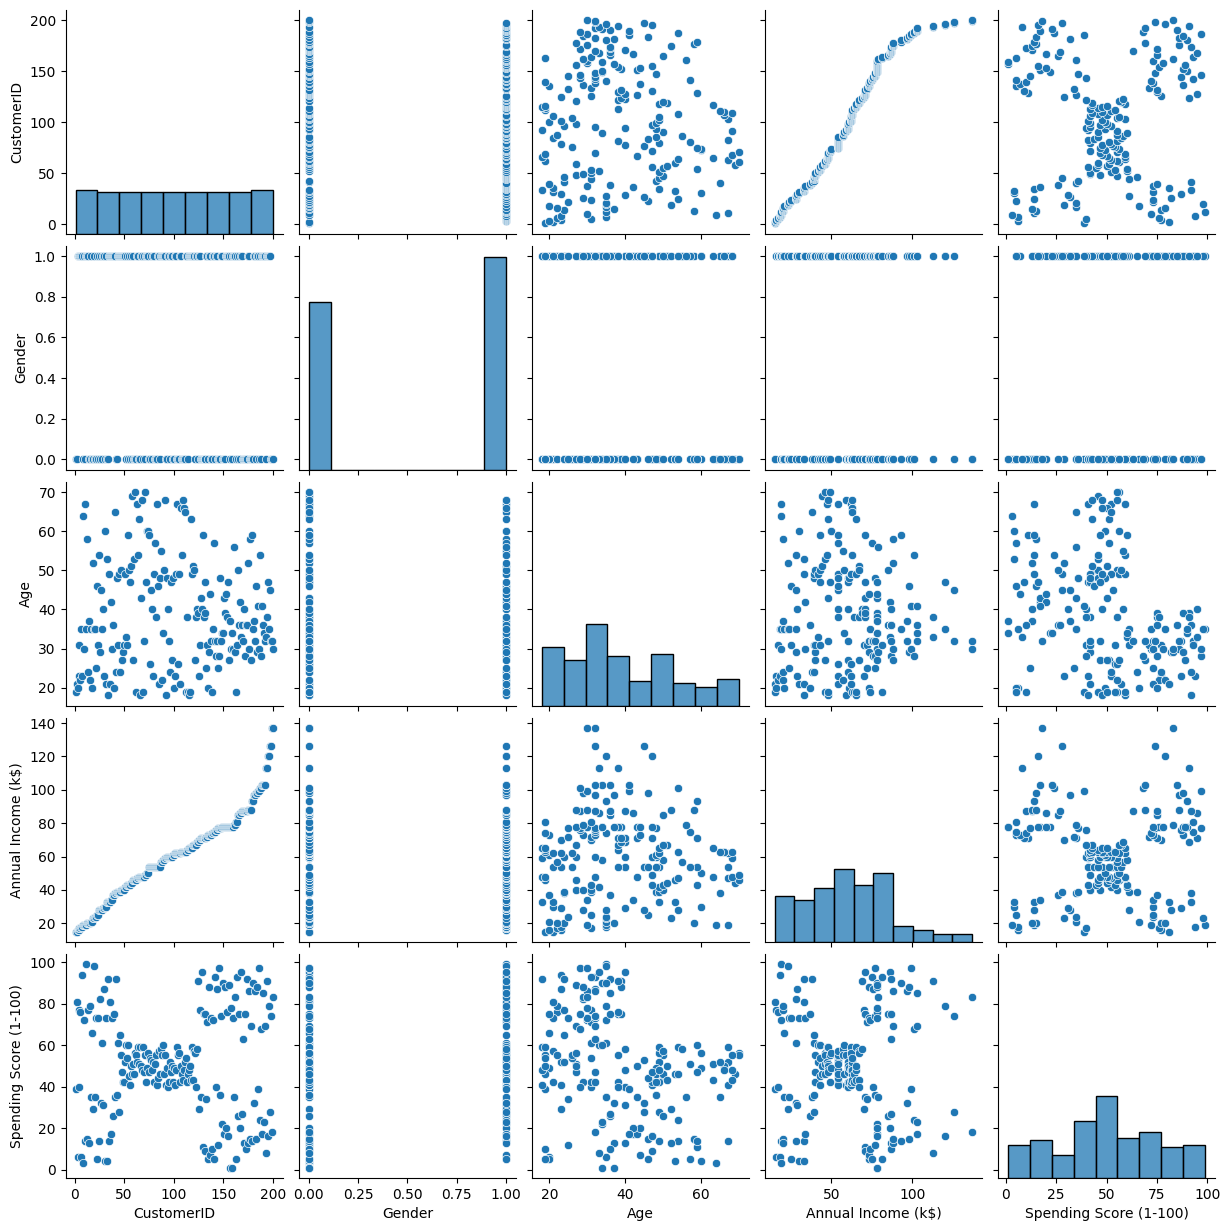

In [ ]:
# Matrice de Correlation
corr_matrix=dataset.corr()
print("La matrice de Correlation :",corr_matrix)

# TODO :Affichage en Heatmap

# Scatter Plot
sns.pairplot(dataset, kind='scatter')
plt.show()

# 4. Feature engineering / sélection: 

In [ ]:
# Supprimer les features non informatives et Redondantes
## Supprimer CustomerID car non-informatives
dataset_select=dataset.drop('CustomerID', axis=1)
dataset_select.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,0,19,15,39
1,0,21,15,81
2,1,20,16,6
3,1,23,16,77
4,1,31,17,40


In [ ]:
# Categoriser des Variables
# TODO:
## Categoriser en Classe d'Age
## 19-24: Classe 1
## 25-39: Classe 2


# 5. Reduction de Dimension:


In [ ]:
# Application de PCA pour la Visualisation en 2D
pca = PCA(n_components=2) # 2 Composants

# Separer les features des Targets (X et Y)
## Features: Gender, Age , Annual Income
## Target : Spending Score

X=dataset_select.drop("Spending Score (1-100)",axis=1) # Exclure Spending Score
Y=dataset_select["Spending Score (1-100)"]

# Application du PCA pour Reduire en 2 dimension
X_pca=pca.fit_transform(X)

#Conversion en Dataframe
df_pca=pd.DataFrame(data=X_pca,columns=['component1','component2'])

df_pca.head()

,component1,component2
0,-45.374976,-20.266595
1,-45.393362,-18.266684
2,-44.385275,-19.259655
3,-44.412854,-16.259789
4,-43.486439,-8.250956


# 6. Clustering

In [19]:
# Clustering K means

## Variables pour Stocker les Resultats
inertias = []
silhouettes = []
K_range = range(2, 7)

## 
for i, k in enumerate(K_range, 1):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, labels))

# 
print("Elbow:",inertias)
print("Silhouette",silhouettes)

Elbow: [87228.95732689211, 59574.61698578636, 39551.60942422729, 32820.2253968254, 25796.078872994825]
Silhouette [0.42272827955403725, 0.42270759995315615, 0.4331549993604238, 0.40145047457459926, 0.40173227570540376]


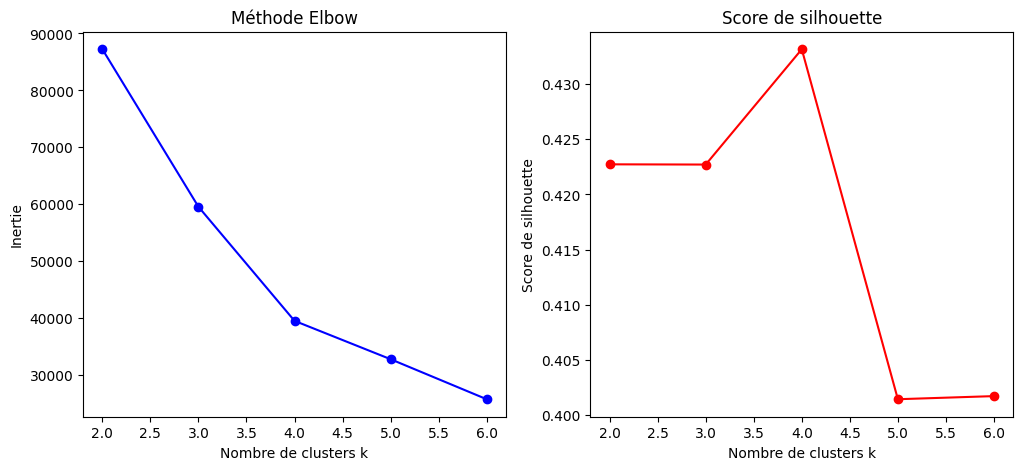

In [24]:
# Affichage de Elbow et Sihouettes

plt.figure(figsize=(12,5))

plt.subplot(1, 2, 1)
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertie')
plt.title('Méthode Elbow')

plt.subplot(1, 2, 2)
plt.plot(K_range, silhouettes, 'ro-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette')

plt.show()

# 7. Interpretation des Clusters

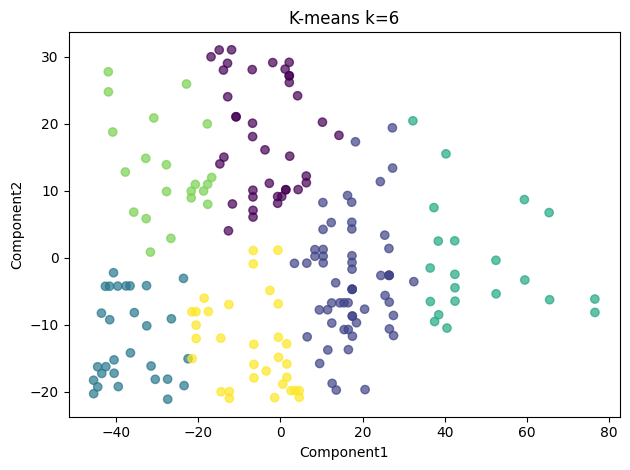

In [ ]:
# Analyses Des Centroides

# TODO : analyse des centroides

# Visualisation 2D Coloré par Cluster
#plt.figure(figsize=(15, 5))

#for i, k in enumerate(K_range, 1):
    # Visualisation clusters en 2D
#plt.subplot(1, len(K_range), i)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', alpha=0.7)
plt.title(f'K-means k={k}')
plt.xlabel('Component1')
plt.ylabel('Component2')

plt.tight_layout()
plt.show()